# Análitica de Datos para Negocios Digitales

## Practica 02: Introduccion al uso de Python en el Analisis de Datos

Elaborado por: Ilse Guadalupe Saavedra Villa

Grado/Grupo: 9 A IEVND

Matrícula: 230349

**1. Importamos las librerias de Python para la manipulación y analisis de datos**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mat
import seaborn as sea

**2. Creamos un DataFrame del Origen de los Datos en este caso un archivo delimitado por comas**

Este comando permite cargar en memoria cache (temporal), los datos que se van a analizar esto utilizando la libreria PANDAS que nos permite la manipulacion de datos.

In [ ]:
df=pd.read_csv('UberDataset.csv')


**3. Imprimimos en pantalla los datos cargados para verificar la carga correcta**

Importante: La impresion de los datos del DATAFRAME no da contexto importante  como el numero de filas, el numero de columnas y en caso de datos CUANTITATIVOS  una suma del total de la columna , en caso de los datos CUALITATIVOS nos colocará en texto NaN ( Not as Number) por defecto por no se pueden sumar.

In [ ]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**4. Leer los datos de una columna especifica**

El uso de COLUMNA nos permite poder acceder a los datos de la columna del dataframe mostrando los 5 primeros y 5 ultimos, el total de registros y el tipo de datos, cabe mencionar que este comando.

In [ ]:
df['PURPOSE']

0        Meal/Entertain
1                   NaN
2       Errand/Supplies
3               Meeting
4        Customer Visit
             ...       
1151     Temporary Site
1152            Meeting
1153     Temporary Site
1154     Temporary Site
1155                NaN
Name: PURPOSE, Length: 1156, dtype: object

**5. Manipulamos los datos cargados para obtener el total de cada valor registrado en la columna**

El metodo value_counts() e una función preprogramada de Python que nos permite agrupar los registro por sus valores y obtener el total de cada valor detectado.()

In [ ]:
df['PURPOSE'].value_counts()

PURPOSE
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Charity ($)          1
Commute              1
Name: count, dtype: int64

**6. Aplicamos la misma función con otra columna**

En este caso vemos que tipos de viaje hizo el conductor, resultando "Bussiness" (Negocios) o "Personal" (Asuntos Personales)

In [ ]:
df['CATEGORY'].value_counts()

CATEGORY
Business    1078
Personal      77
Name: count, dtype: int64

**7. Limpiamos los registros de los viajes que no tienen una localización de inicio.**

Para este analisis es importante limpiar los datos de la muestra que nos sirven para nuestro analisis, empezaremos por eliminar los registros (Filas) de aquellos viajes que nos registraron un destino localizable. Para ello utilizamos el comando logico de no igualdad (!=) pára filtrar el dataframe, esto nos arrojara un resultado de booleano "True" para los qu etienen un destino localizable y "False" para los que no.

In [ ]:
df['STOP']!='Unknown Location'

0        True
1        True
2        True
3        True
4        True
        ...  
1151    False
1152    False
1153     True
1154     True
1155     True
Name: STOP, Length: 1156, dtype: bool

**8. Limpiamos los registros de los viajes que no tienen una localizacion de inicio.**

In [ ]:
df=df[df['STOP']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**9. Sobreescribimos del dataframe (df)**

Para eliminar de nuestro analisis, es decir que el documento de origwn de los datos (csv) sigue sin cambios adignamos el resultado del filtrado.

In [ ]:
df=df[df['START']!='Unknown Location']

**10. Volvemos a imprimir el dataframe**

En este resultado podemos observar que el numero dataframe cuenta solo con 1007 filas a diferencia del original que tenia 1156, es decir se eliminaron 149 registros que no tenian un destino localizable.

In [ ]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**11. Repetimos el proceso de limpieza ahora para los viajes que no tienen un origen localizable (START)**

En este caso realizamos toda la limpieza en una sola operación, obteniendo una actualizaciobn del df que ocuparemos para el analisis de datos reduciendo de 1007 a 945 registros, intuyendo que hay 2 viajes que tuvieron un destino (STOP) pero no un origen (START)

In [ ]:
df=df[df['START']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**LIMPIAMOS LOS REGISTROS DE LOS VIAJES QUE NO SON LOCALIZABLES**

In [ ]:
def value(val):
    val=str(val)
    return val.replace('?','a')
df['START']=df['START'].apply(value)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**12. Conceptos de Repaso**

12.1 Funciones o Metodos en Python.
    Una funcion o método es un bloque de código reutilizable que realiza una tarea especifica. Sirve para evitar repetir instrucciones y organizar mejor los programas.

En el lenguaje de Programación de Python las funciones son declaradas con la oalabra reservada def, y para ejecutarlas basta con escribir el nombre que se le asigno a la misma, el uso de () es para enviar los datos de entrada en caso de que sean necesarios.

Definición:

In [ ]:
def saludar():
    print("Hola, Bienvenid@ a Python para el Análisis de Datos")

Llamada:

In [ ]:
saludar()

Hola, Bienvenid@ a Python para el Análisis de Datos


12.2 Funciones que reciben un parametro o datos de entrada. En algunas ocasiones es necesario enviar datos para a ejecuion del metodo, para ello debemos declararlo en la definicion de la funcion entre ()

Definición:

In [ ]:
def saludar_nombre(nombre):
    return f"Hola, {nombre} Bienvenid@ a Python para el Análisis de Datos"

In [ ]:
saludar_nombre("Marco")

'Hola, Marco Bienvenid@ a Python para el Análisis de Datos'

In [ ]:
saludar_nombre("Lupita")

'Hola, Lupita Bienvenid@ a Python para el Análisis de Datos'

12.3 Funciones que mandan llamar otras funciones y que regresan el resultado de un procesamiento, en este caso utilizaremos una funcion predefinida en Python denominada replace que nos permite sustituir letras en una cadena de texto.

Definición:

In [ ]:
def sustituir_vocales(texto):
    texto = texto.replace("A", "4")
    texto = texto.replace("a", "4")

    texto = texto.replace("E", "3")
    texto = texto.replace("e", "3")

    texto = texto.replace("I", "1")
    texto = texto.replace("i", "1")

    texto = texto.replace("O", "0")
    texto = texto.replace("o", "0")

    texto = texto.replace("U", "∪")
    texto = texto.replace("u", "∪")

    return texto

Llamado:

In [ ]:
print(sustituir_vocales(saludar_nombre("Marco")))

H0l4, M4rc0 B13nv3n1d@ 4 Pyth0n p4r4 3l 4nál1s1s d3 D4t0s


13. Limpieza de letras ilegibles

Ejecutamos el proceso de sustitucion de las letras ilegible (para este caso de estudio solo hay letras a con tilde que se cargaron con un ?, y se limpian cobn una "a" para mejor comprensión del analisis.

In [ ]:
df['START'] = df['START'].astype(str).str.replace('?','a')
df['STOP'] = df['STOP'].astype(str).str.replace('?','a')
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


14. **Rellenar datos vacios por un valor genérico asignado**

Durante el proceso de Limpieza y Transformacion de los datos, existe la posibilidad de corregir datos que no se encuentran registrados, para este caso usaremos una funciones de **PANDAS** llamada *fillna*, (sirve para rellenar los datos no disponibles (not available).

In [ ]:
df['PURPOSE'].fillna('Others', inplace=True)
df

C:\Users\PC-13\AppData\Local\Temp\ipykernel_11948\2042178618.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PURPOSE'].fillna('Others', inplace=True)


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


15. **Medidas de Tendnci Central**

Una ves terminada la fase de limpieza de datos, comenzamos con la Estadistica Basica, en este caso consultaremos las medidas de tendencia central siendo: Total, Media, Cuartiles y Desviación Estándar, Maximo y Minimo.

Utilizando en metodo **describe** de nuestro dataframe, se buscaran todos los datos cuantitativos (Numericos) de la muestra y realizara el calculo de estos valores, para este caso en especifico solo tenemos la columna **MILES**, la cual hace referencia al total de Millas Terrestreas (1.609 km) recorridas por el conductor en un servicio de viaje a traves de UBER.

In [ ]:
df.describe()

,MILES
count,945.000000
mean,22.809841
std,397.276813
min,0.500000
25%,2.600000
50%,5.300000
75%,9.900000
max,12204.700000


Para el caso de Mediana y Moda, estas deben ser calculadas por separado a través de las fuciones mode y median

In [ ]:
print(df['MILES'].mode())

0    9.9
Name: MILES, dtype: float64


In [ ]:
print(df['MILES'].median())

5.3


En **CONCLUSIÓN** este dataframe nos permite analizar una pequeña muestra de **945** Viajes realizados a traves de la aplicacion de UBER, determinando que la distancia minima registrada es de **.5** millas y las máxima de **12204.7** millas, con un promedio de **22.8** millas, siendo la distancia mas repetida de 9.9 millas y la mediana de 5.3 millas.

**16. Limpieza de Datos: Segmentar la Fecha del Viaje, ignorando la HH:MM:SS**

In [ ]:
def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-','/')
df['START_DATE']=df['START_DATE'].apply(val)

def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-','/')
df['END_DATE']=df['END_DATE'].apply(val)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01/06/2016,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016,12/31/2016,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**17. Eliminamos la ultima fila de totales**

La ultima fila de totales no es necesaria para la graficacion dado que podria generar error en la representacion de datos, por ello la eliminamos del Dataframe usando el comando drop y el numero de la posicion de la fila a eliminar encerrada dentre corchetes[]

In [ ]:
df.drop([1155], inplace=True)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01/06/2016,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016,Business,Katunayake,Gampaha,6.4,Temporary Site


Ejercicio: Documentar que hace y ¿Por que lo hace?

**18. Filtrado de Valores Atípicos (Outliers)**

Una vez obtenidas las medidas de tendencia central, es necesario realizar una depuración más profunda de los datos para asegurar que valores extremos no sesguen nuestro análisis. En este paso, aplicaremos un filtrado basado en cuantiles para delimitar el rango de estudio de la columna MILES.

Utilizando el cálculo de los cuantiles 0.05 (límite inferior) y 0.95 (límite superior), se busca segmentar la muestra para conservar el 90% de los datos centrales, eliminando aquellos viajes con distancias inusualmente cortas o extremadamente largas que podrían considerarse errores de registro o casos excepcionales.

In [ ]:
a = df['MILES'].quantile(0.95)
b = df['MILES'].quantile(0.05)
df3 = df[df['MILES']>b]
df3 = df[df['MILES']<a]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting


**19. Calculo de la Desviaxion Estandar**

Para entender que tan variables o dispersas son las distancias de los viajes.

In [ ]:
df3['STD']=df.MILES.std()
df3

C:\Users\PC-13\AppData\Local\Temp\ipykernel_11948\672307851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['STD']=df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805
...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805


**20. Estimar el valor de Z-Score o Puntuacion Z**

Con la finalidad de estimar la dispercion de los datos, es decir que tan variados o diferentes son, utilizamos esta formula estadistica para poder continuar con el análisis EDA(Exploratory Data Analisys).

In [ ]:
df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()
df3

C:\Users\PC-13\AppData\Local\Temp\ipykernel_11948\2738585948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805,-0.228442
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


**21. Filtramos aquello que no esten en el rango de -1 y 1**



In [ ]:
df['MILES'].describe()

count    944.000000
mean       9.905297
std       21.472805
min        0.500000
25%        2.600000
50%        5.300000
75%        9.900000
max      310.300000
Name: MILES, dtype: float64

In [ ]:
df3['MILES'].describe()

count    896.000000
mean       6.344196
std        4.849186
min        0.500000
25%        2.500000
50%        4.900000
75%        9.025000
max       25.600000
Name: MILES, dtype: float64

In [ ]:
df3=df3[(df3.Z>-1) & (df3.Z<1)]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805,-0.228442
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


**22. Graficacion Basica para un Analisis mas visual y simplificado**

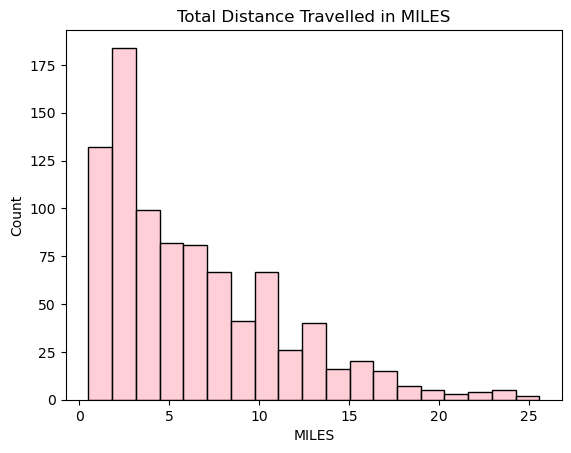

In [ ]:
mat.title('Total Distance Travelled in MILES')
sea.histplot(df3.MILES,color='Pink')
mat.show()

**23. Grafico de Clasificacion de Viajes por CATEGORIA**


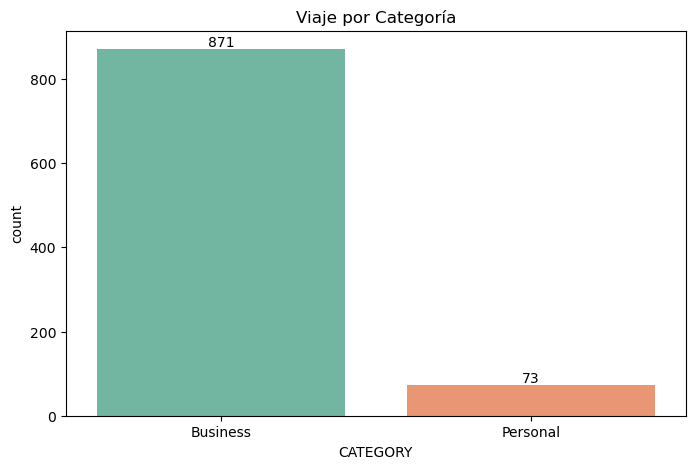

In [ ]:
fig, ax = mat.subplots(figsize=(8, 5))

grafica = sea.countplot(
    data=df,
    x='CATEGORY',
    hue='CATEGORY',
    palette='Set2',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Viaje por Categoría')

# Agregar etiquetas con totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()

**24. Grafica de Viajes por proposito (PURPOSE)**

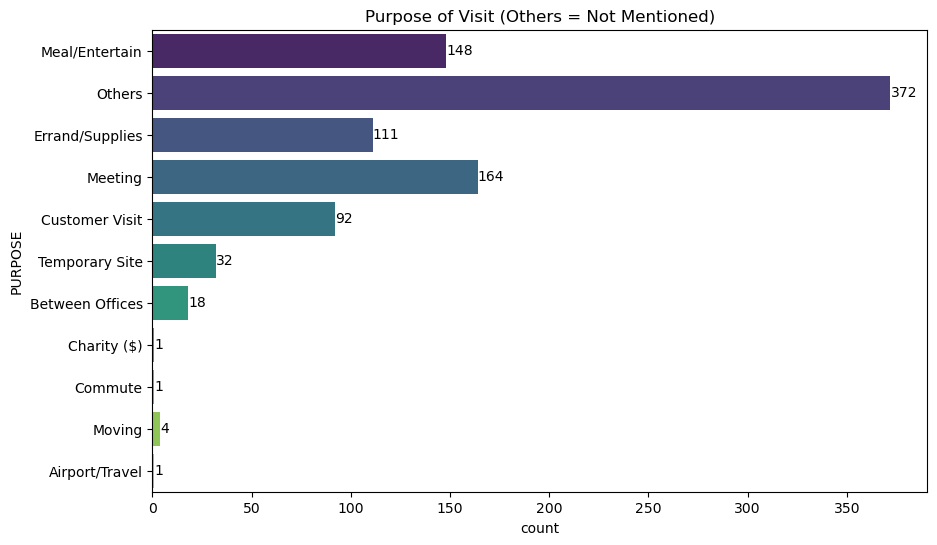

In [ ]:
fig, ax = mat.subplots(figsize=(10, 6))

grafica = sea.countplot(
    data=df,
    y='PURPOSE',
    hue='PURPOSE',
    dodge=False,
    palette='viridis',
    legend=False
)

# Título
ax.set_title('Purpose of Visit (Others = Not Mentioned)')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()

**25. Grafico de Lugar de Abordaje (START)**

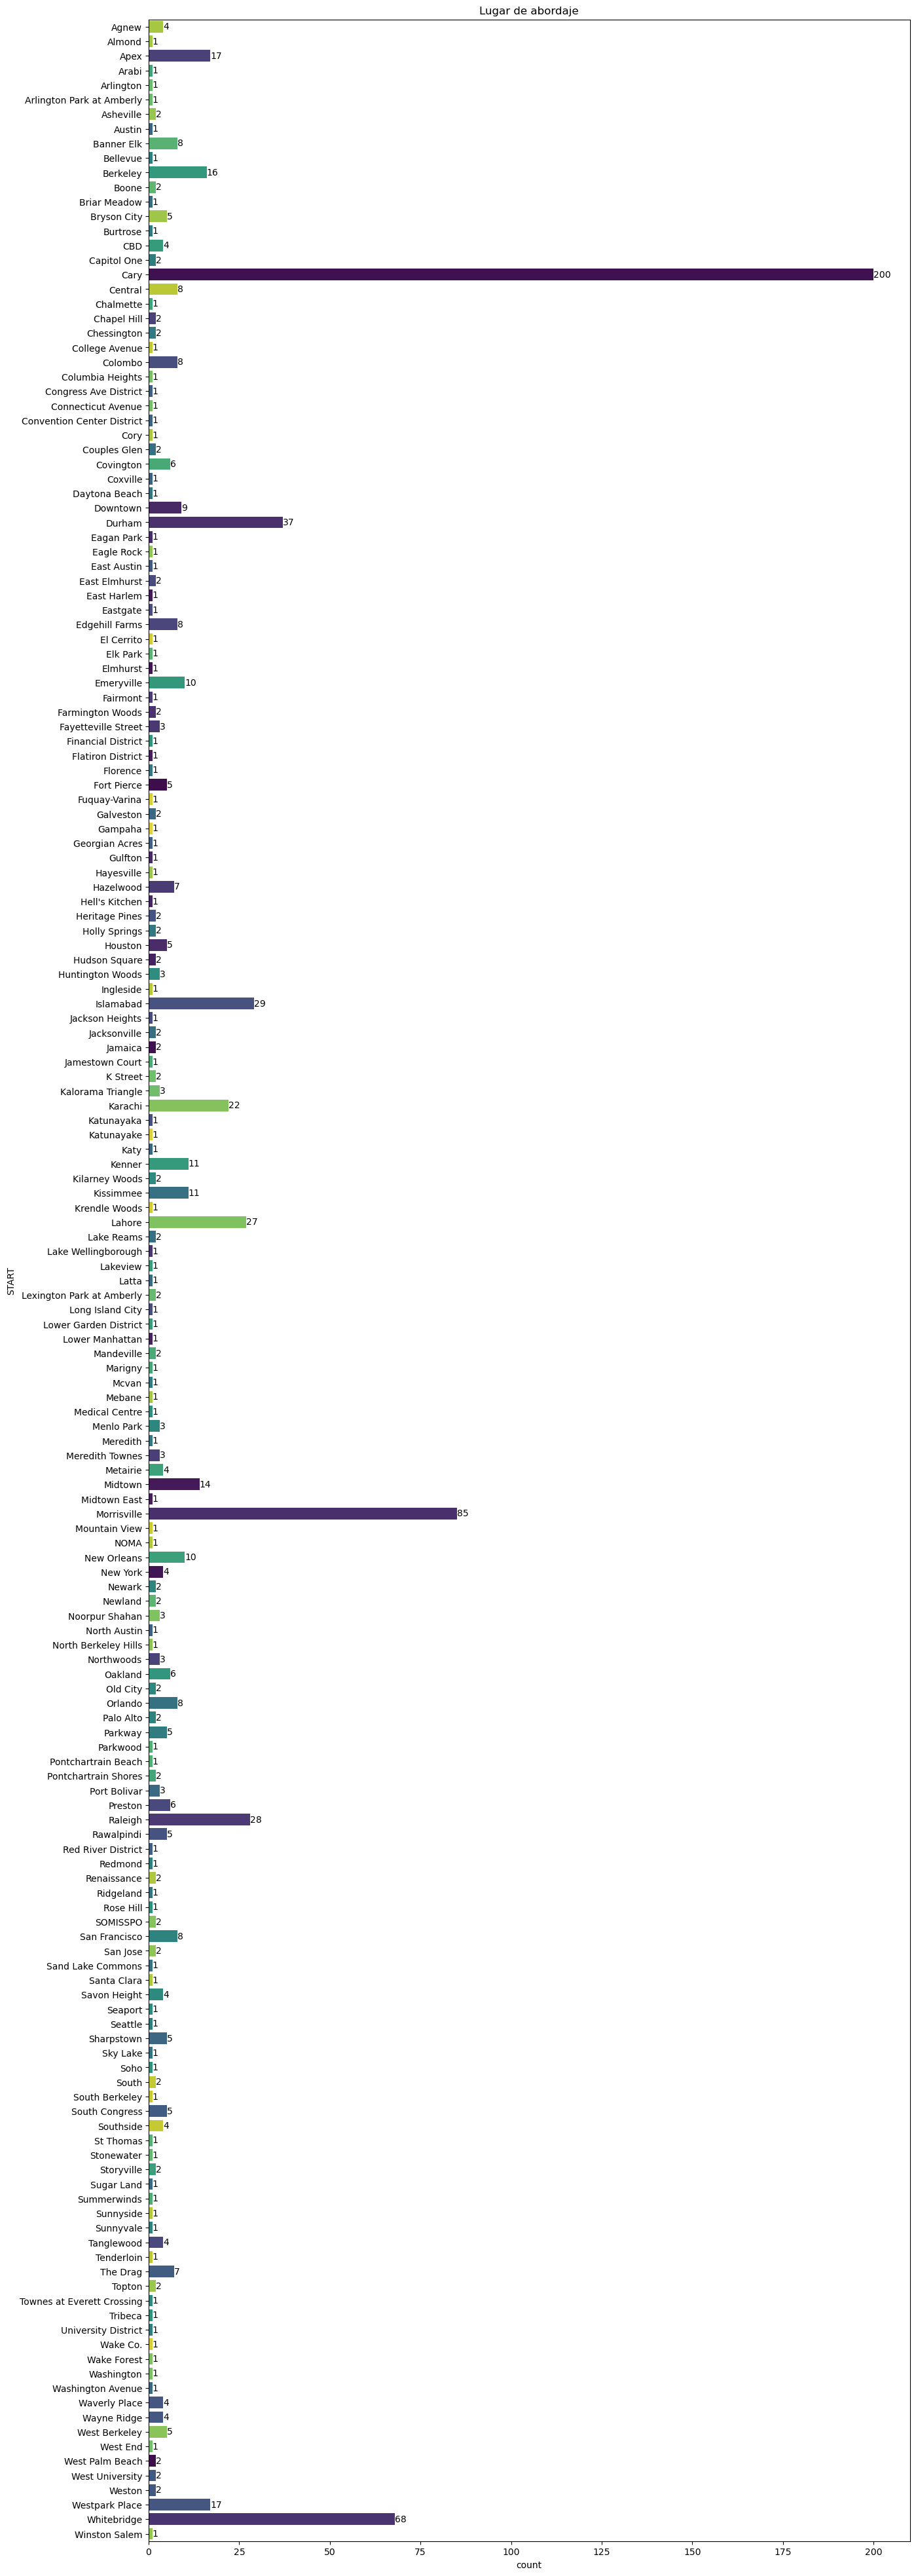

In [ ]:
fig, ax = mat.subplots(figsize=(15, 50))

# Ordenar alfabéticamente
orden = sorted(df['START'].dropna().unique())

grafica = sea.countplot(
    data=df,
    y='START',
    order=orden,
    hue='START',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Lugar de abordaje')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()

**26. GRAFICA DE lUGAR DE LLEGADA (stop)**

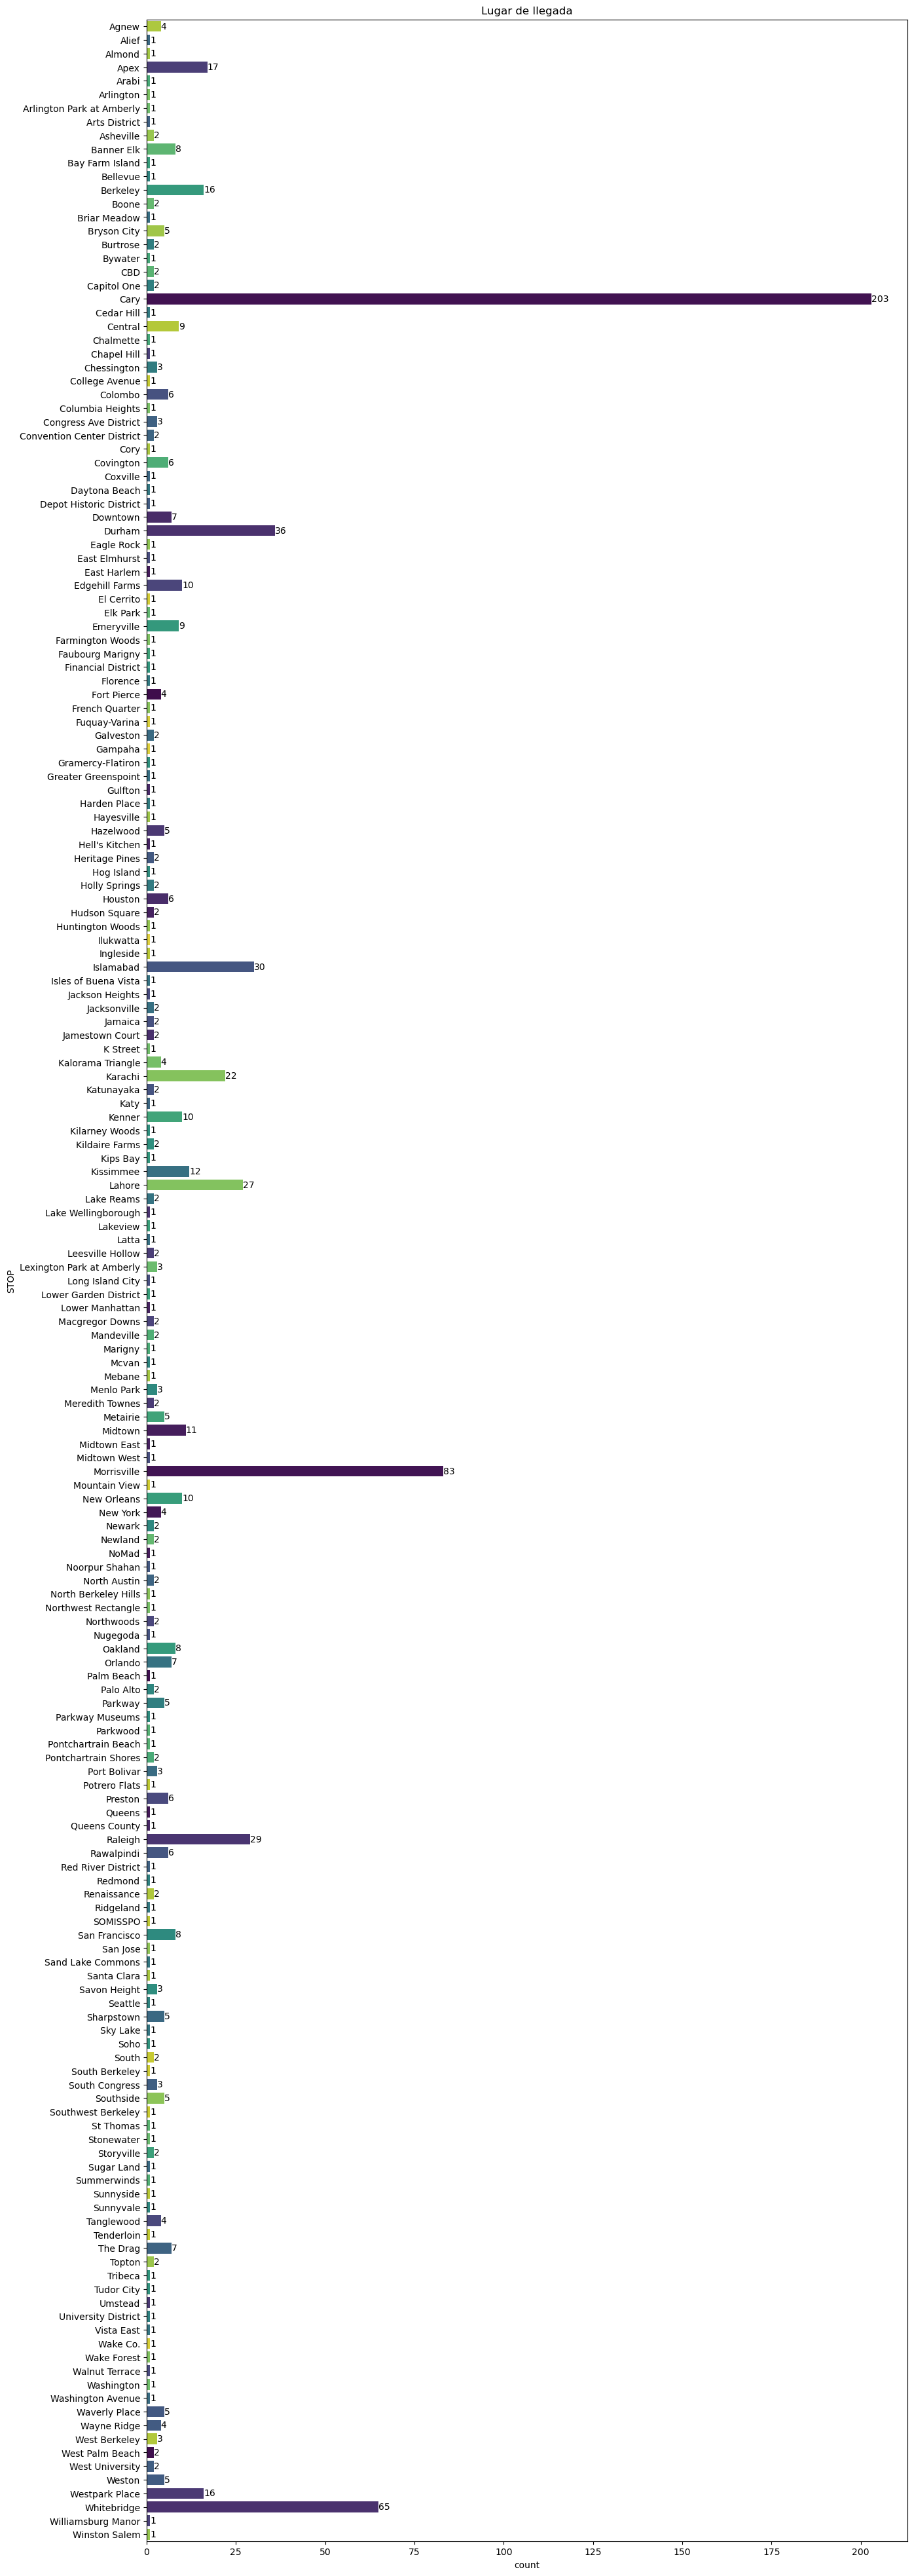

In [ ]:
fig, ax = mat.subplots(figsize=(15, 50))

# Ordenar alfabéticamente
orden = sorted(df['STOP'].dropna().unique())

grafica = sea.countplot(
    data=df,
    y='STOP',
    order=orden,
    hue='STOP',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Lugar de llegada')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()

**27. CONCLUSIONES**

A través de este análisis de datos con Python, se logró identificar patrones clave en el uso de Uber, donde las gráficas de barras y de dispersión fueron fundamentales para visualizar la predominancia de viajes de negocios y las rutas más frecuentes. La limpieza del dataset permitió obtener estadísticas más precisas, como el cálculo del Z-Score, que ayudó a detectar trayectos atípicos en las distancias recorridas. En conclusión, el uso de librerías como Pandas y Seaborn no solo facilita la organización de grandes volúmenes de información, sino que transforma datos crudos en conocimiento estratégico mediante una interpretación visual clara y profesional de los hábitos de transporte.